# Comprensión y análisis exploratorio de datos (EDA)

Este notebook realiza el análisis exploratorio de los datos históricos de créditos cargados en `Cargar_datos.ipynb`.

Objetivos:
- Entender la estructura, calidad y distribución de las variables.
- Identificar valores nulos, outliers y desbalance de clases.
- Explorar relaciones entre las variables y la variable objetivo `Pago_atiempo`, que indica si el crédito fue pagado a tiempo (1) o no (0).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

BASE_DIR = Path.cwd().parent
DATA_PATH = BASE_DIR / "Base_de_datos.xlsx"

TARGET = "Pago_atiempo"

## 1. Carga de datos desde el archivo fuente

In [2]:
df = pd.read_excel(DATA_PATH, sheet_name="Hoja1")

print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.head()

Filas: 10763, Columnas: 23


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,695.0,10,5,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,789.0,3,1,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,740.0,4,5,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,837.0,4,4,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,771.0,4,6,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


## 2. Estructura general y calidad de los datos

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tipo_credito                   10763 non-null  int64         
 1   fecha_prestamo                 10763 non-null  datetime64[us]
 2   capital_prestado               10763 non-null  float64       
 3   plazo_meses                    10763 non-null  int64         
 4   edad_cliente                   10763 non-null  int64         
 5   tipo_laboral                   10763 non-null  str           
 6   salario_cliente                10763 non-null  int64         
 7   total_otros_prestamos          10763 non-null  int64         
 8   cuota_pactada                  10763 non-null  int64         
 9   puntaje                        10763 non-null  float64       
 10  puntaje_datacredito            10757 non-null  float64       
 11  cant_creditosvigentes     

In [4]:
# Nulos por columna (cantidad y porcentaje)
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({"nulos": nulos, "porcentaje": nulos_pct})
resumen_nulos = resumen_nulos[resumen_nulos["nulos"] > 0].sort_values("nulos", ascending=False)
resumen_nulos

,nulos,porcentaje
tendencia_ingresos,2932,27.24
promedio_ingresos_datacredito,2930,27.22
saldo_mora_codeudor,590,5.48
saldo_principal,405,3.76
saldo_mora,156,1.45
saldo_total,156,1.45
puntaje_datacredito,6,0.06


In [5]:
print(f"Filas duplicadas: {df.duplicated().sum()}")

Filas duplicadas: 0


## 3. Estadísticas descriptivas

Se separan las variables numéricas y categóricas para analizarlas por separado. `tipo_credito` se trata como categórica porque representa un código de producto, no una magnitud.

In [6]:
cat_cols = ["tipo_credito", "tipo_laboral", "tendencia_ingresos"]
num_cols = [c for c in df.columns if c not in cat_cols + [TARGET, "fecha_prestamo"]]

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: ['capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito']
Categóricas: ['tipo_credito', 'tipo_laboral', 'tendencia_ingresos']


In [7]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
capital_prestado,10763.0,2.434315e+06,1.909643e+06,360000.00000,1.224831e+06,1.921920e+06,3.084840e+06,4.144415e+07
plazo_meses,10763.0,1.057558e+01,6.632082e+00,2.00000,6.000000e+00,1.000000e+01,1.200000e+01,9.000000e+01
edad_cliente,10763.0,4.394862e+01,1.506088e+01,19.00000,3.300000e+01,4.200000e+01,5.300000e+01,1.230000e+02
salario_cliente,10763.0,1.721643e+07,3.554767e+08,0.00000,2.000000e+06,3.000000e+06,4.875808e+06,2.200000e+10
total_otros_prestamos,10763.0,6.238870e+06,1.184183e+08,0.00000,5.000000e+05,1.000000e+06,2.000000e+06,6.787675e+09
cuota_pactada,10763.0,2.436174e+05,2.104937e+05,23944.00000,1.210415e+05,1.828630e+05,2.878335e+05,3.816752e+06
puntaje,10763.0,9.117004e+01,1.646544e+01,-38.00999,9.522779e+01,9.522779e+01,9.522779e+01,9.522779e+01
puntaje_datacredito,10757.0,7.807908e+02,1.048780e+02,-7.00000,7.570000e+02,7.910000e+02,8.250000e+02,9.990000e+02
cant_creditosvigentes,10763.0,5.726749e+00,3.977162e+00,0.00000,3.000000e+00,5.000000e+00,8.000000e+00,6.200000e+01
huella_consulta,10763.0,4.228561e+00,3.064683e+00,0.00000,2.000000e+00,4.000000e+00,6.000000e+00,2.900000e+01


In [8]:
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- tipo_credito ---
tipo_credito
4     7747
9     2876
10     116
6       21
7        2
68       1
Name: count, dtype: int64

--- tipo_laboral ---
tipo_laboral
Empleado         6754
Independiente    4009
Name: count, dtype: int64

--- tendencia_ingresos ---
tendencia_ingresos
Creciente      5294
NaN            2932
Decreciente    1291
Estable        1188
0                 7
8315              6
1000000           4
9147              2
158042            1
3978              1
168750            1
-28589            1
-566272           1
24702             1
31837             1
122727            1
417087            1
9090              1
173031            1
-70715            1
-435177           1
-702927           1
-4105             1
54683             1
22832             1
209090            1
5697              1
10808             1
-288              1
-164315           1
2029000           1
17181             1
15245             1
82657             1
52862             1
1817052           1
7

## 4. Variable objetivo: `Pago_atiempo`

Se revisa el balance de clases, clave para decidir la estrategia de modelado (métricas, remuestreo, etc.).

Pago_atiempo
1    95.25
0     4.75
Name: proportion, dtype: float64


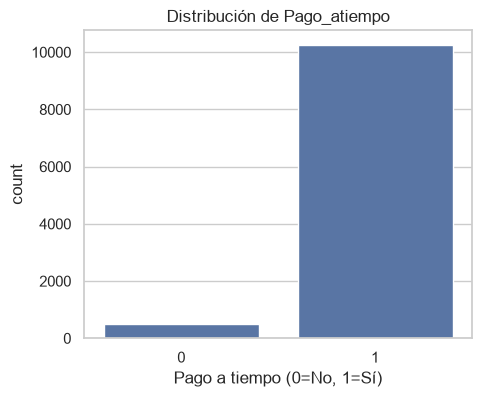

In [9]:
target_counts = df[TARGET].value_counts(normalize=True).mul(100).round(2)
print(target_counts)

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x=TARGET, ax=ax)
ax.set_title("Distribución de Pago_atiempo")
ax.set_xlabel("Pago a tiempo (0=No, 1=Sí)")
plt.show()

## 5. Análisis univariado — variables numéricas

Histogramas para ver la forma de la distribución de cada variable.

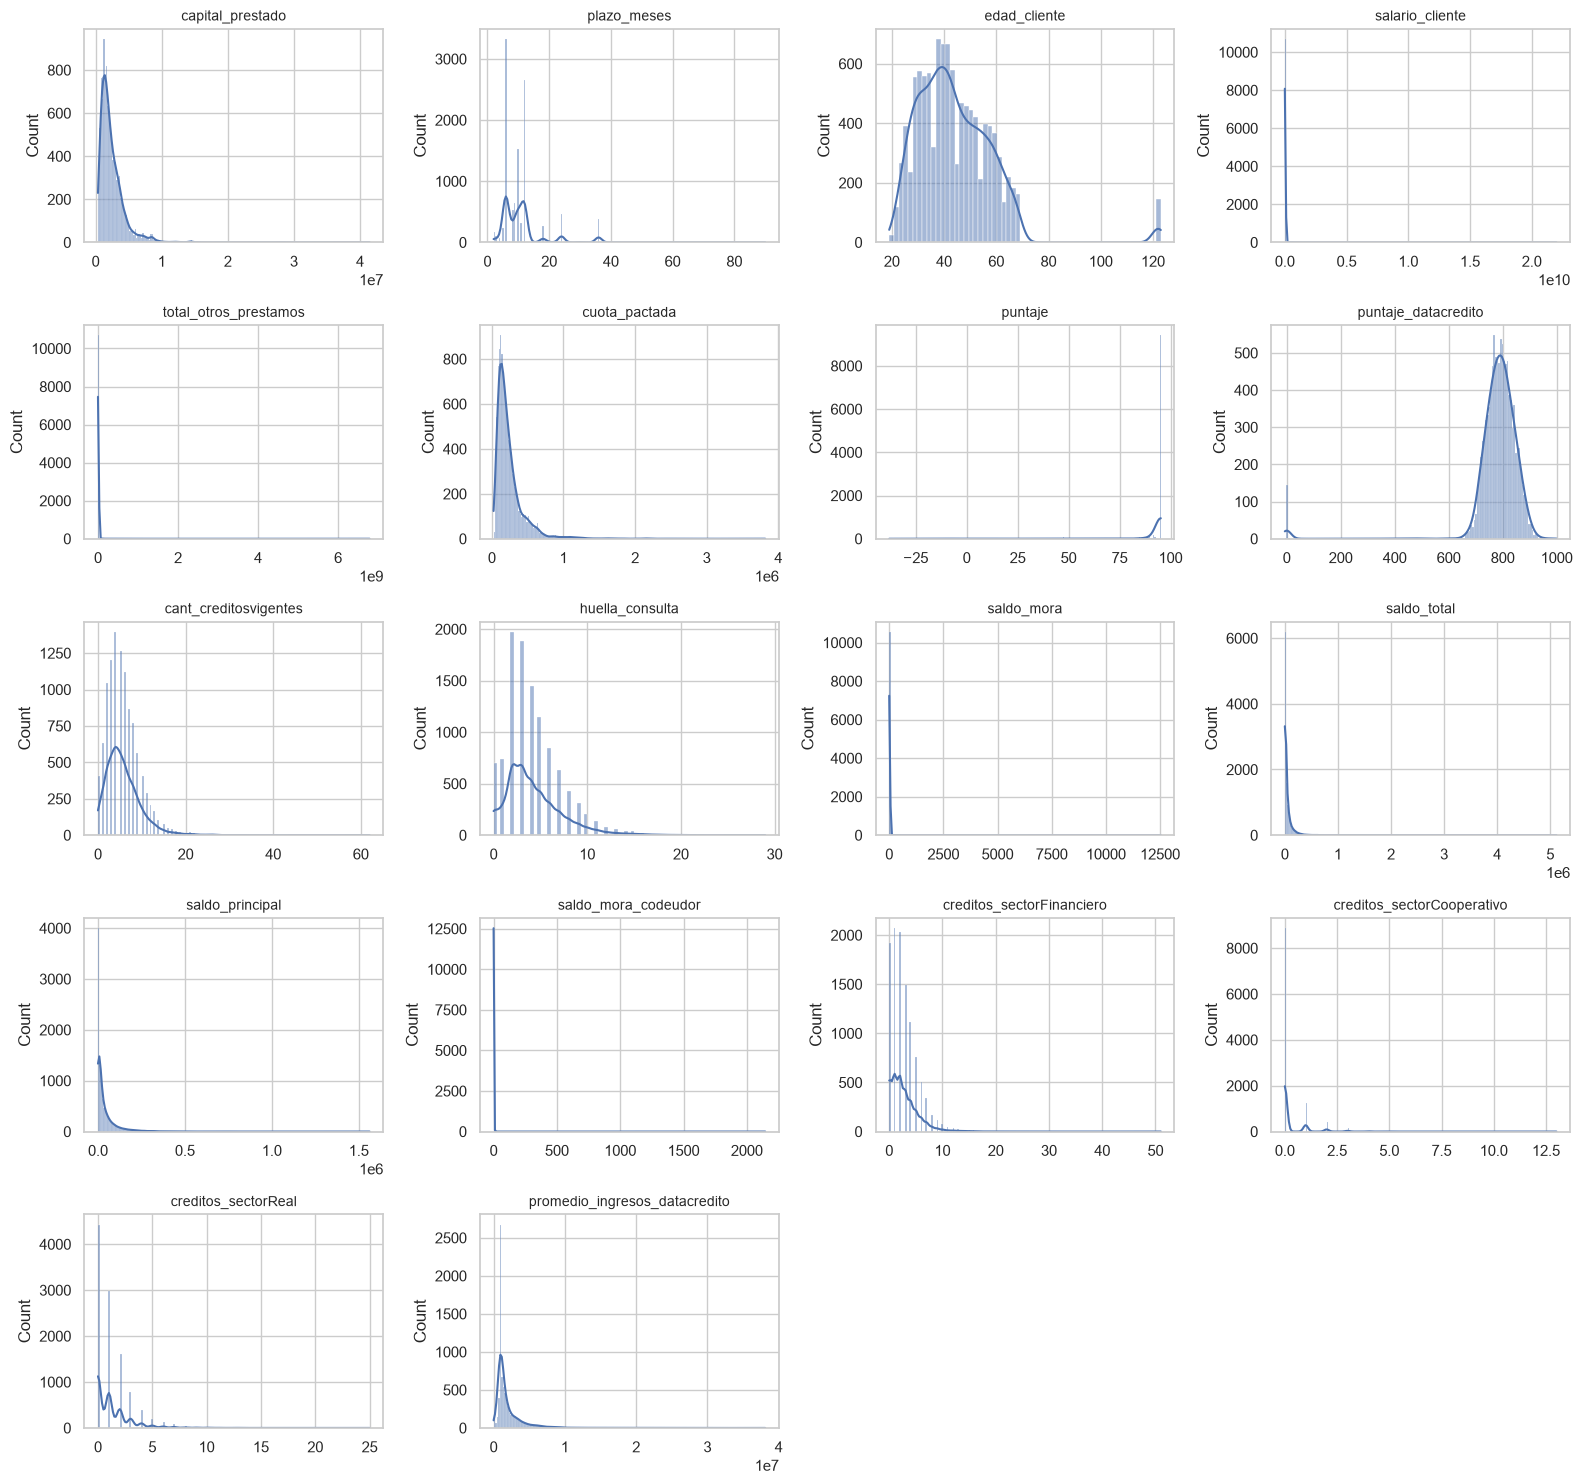

In [10]:
n_cols = 4
n_rows = -(-len(num_cols) // n_cols)  # ceil

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")

for ax in axes[len(num_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

Boxplots para identificar outliers en las variables numéricas.

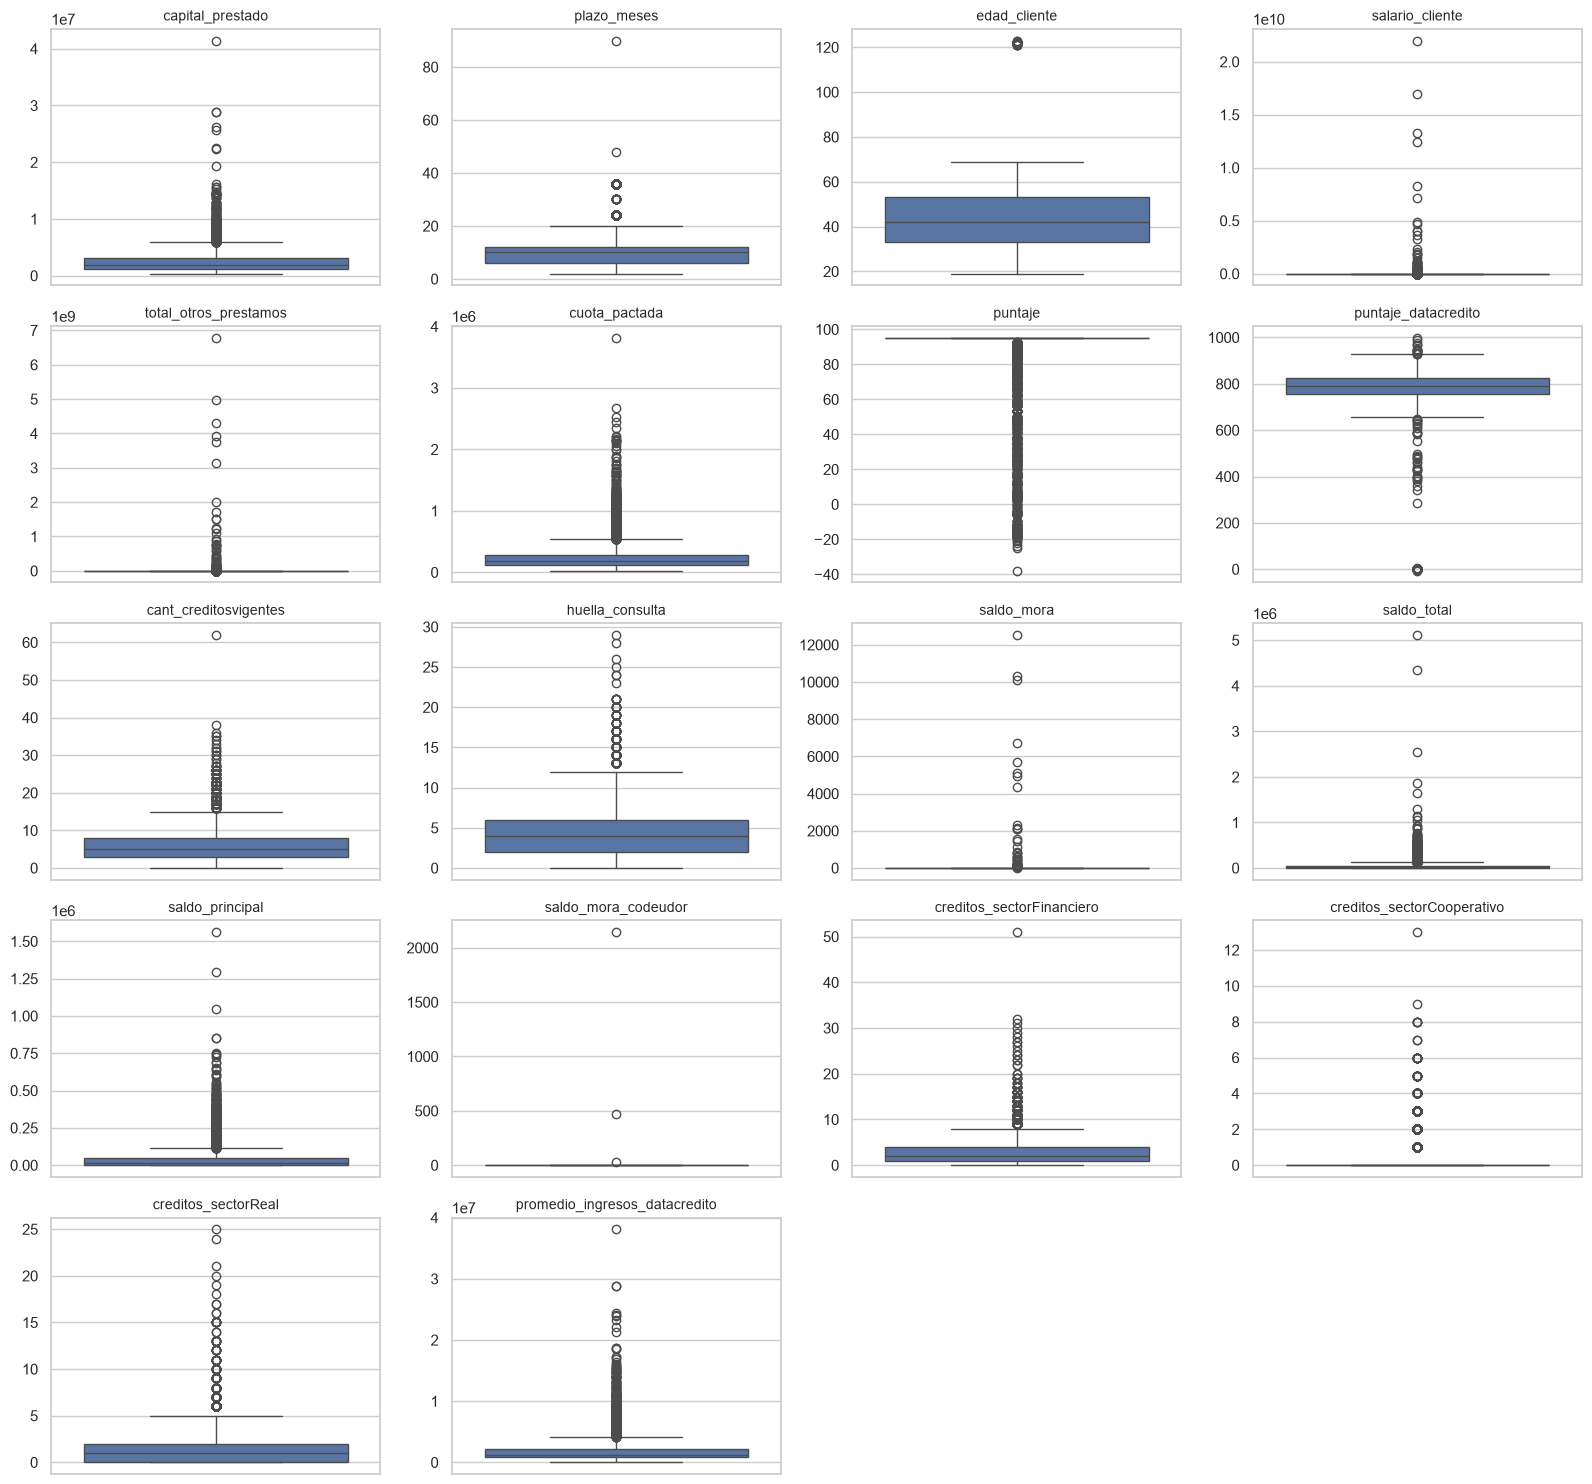

In [11]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col].dropna(), ax=ax)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("")

for ax in axes[len(num_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 6. Análisis univariado — variables categóricas

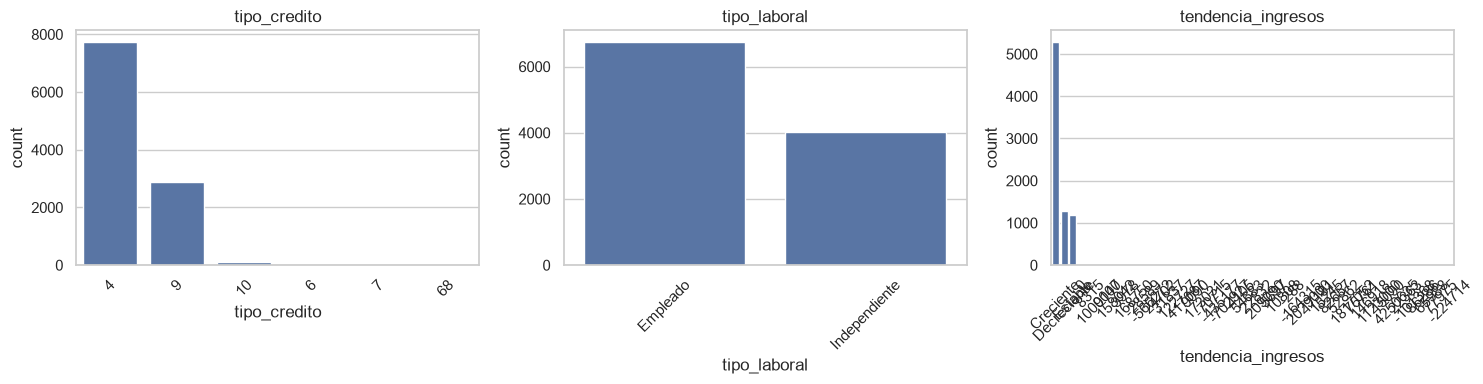

In [12]:
fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 4))

for ax, col in zip(axes, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 7. Correlación entre variables numéricas

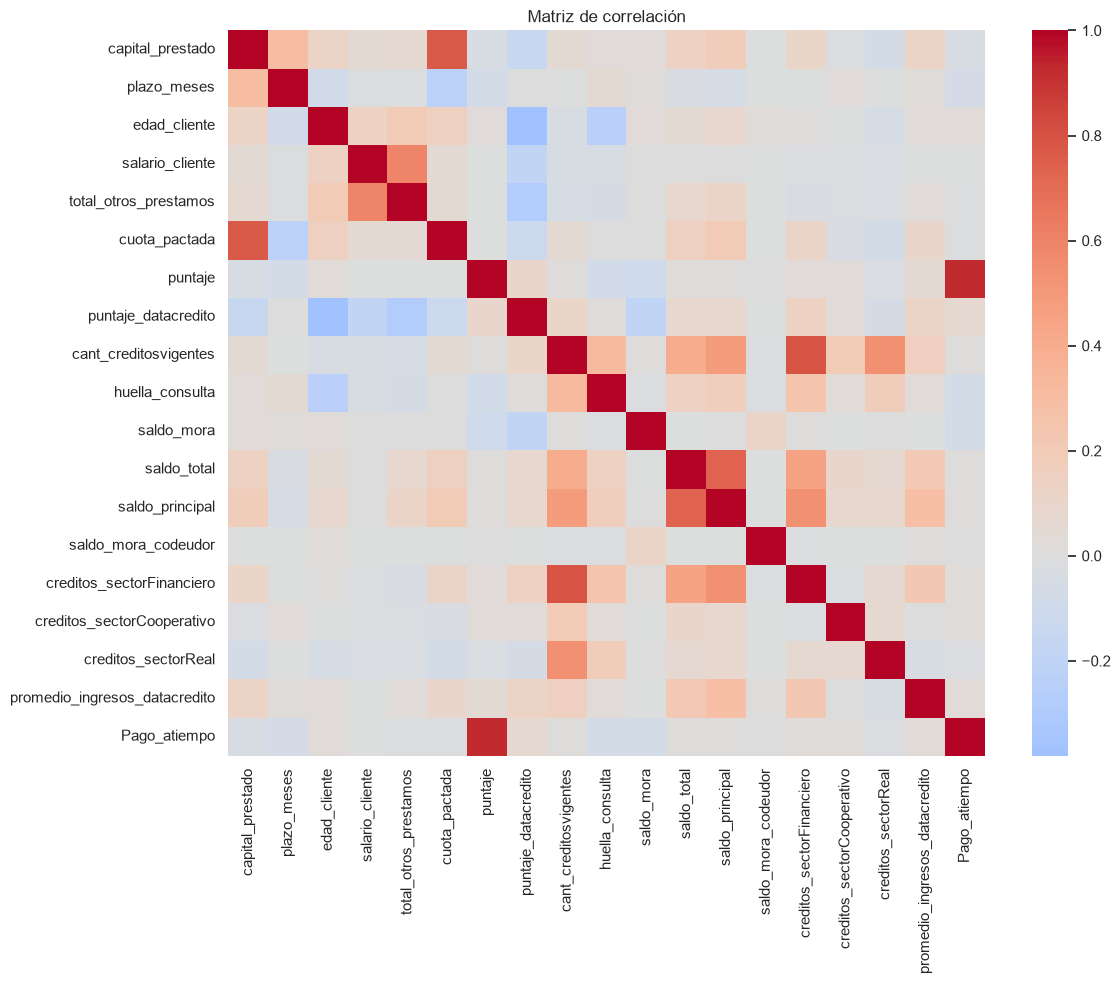

In [13]:
corr = df[num_cols + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, ax=ax)
ax.set_title("Matriz de correlación")
plt.tight_layout()
plt.show()

In [14]:
# Variables numéricas más correlacionadas (en valor absoluto) con la variable objetivo
corr[TARGET].drop(TARGET).abs().sort_values(ascending=False)

puntaje                          0.923134
huella_consulta                  0.073737
saldo_mora                       0.073458
puntaje_datacredito              0.067882
plazo_meses                      0.063105
capital_prestado                 0.040624
promedio_ingresos_datacredito    0.039867
edad_cliente                     0.032252
creditos_sectorReal              0.023306
creditos_sectorFinanciero        0.021390
creditos_sectorCooperativo       0.021267
saldo_total                      0.014364
cuota_pactada                    0.011814
saldo_principal                  0.011473
total_otros_prestamos            0.010041
cant_creditosvigentes            0.008829
salario_cliente                  0.003981
saldo_mora_codeudor              0.002631
Name: Pago_atiempo, dtype: float64

## 8. Variables numéricas vs `Pago_atiempo`

Boxplots comparando la distribución de cada variable numérica según si el crédito se pagó a tiempo o no.

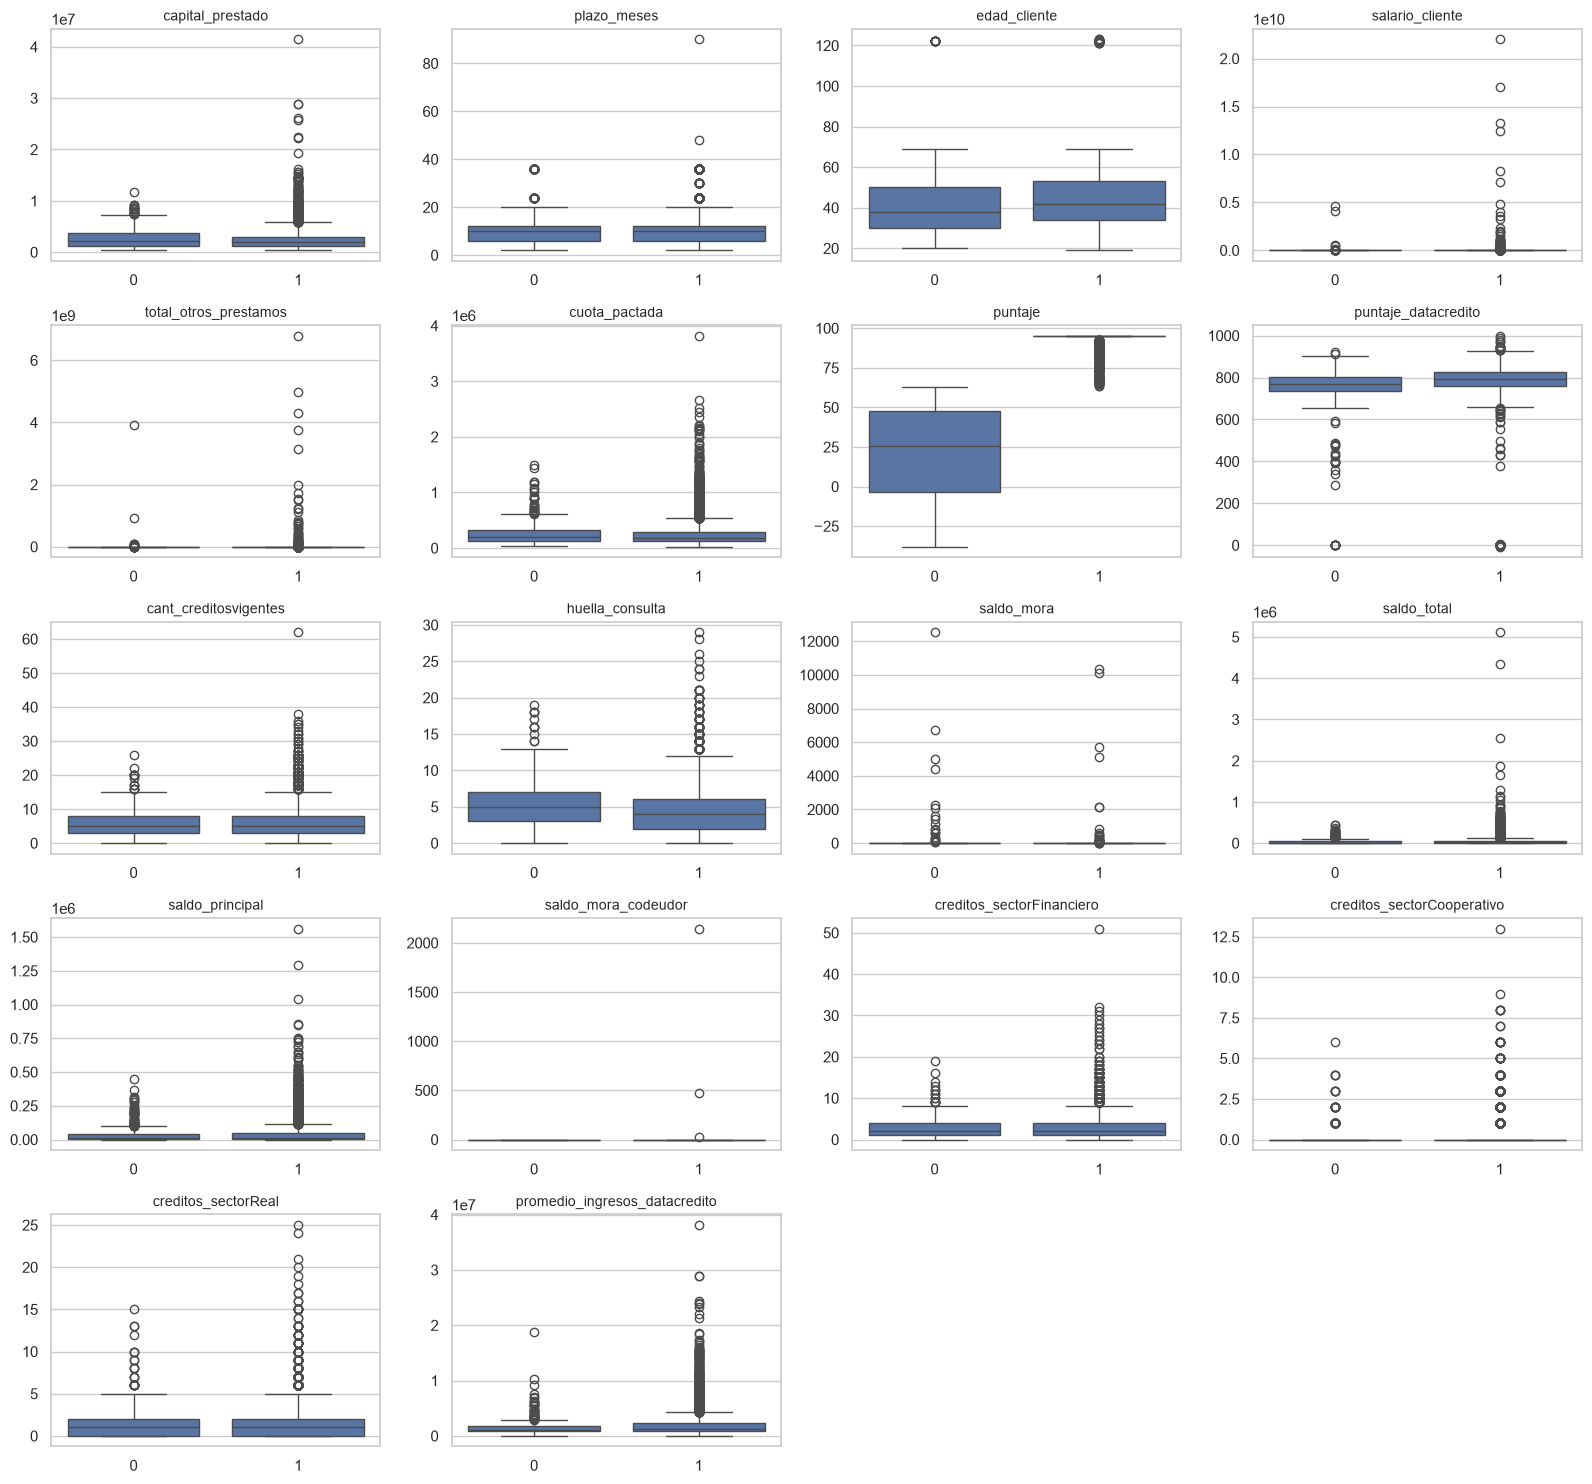

In [15]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x=TARGET, y=col, ax=ax)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[len(num_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 9. Variables categóricas vs `Pago_atiempo`

Tasa de pago a tiempo por cada categoría.

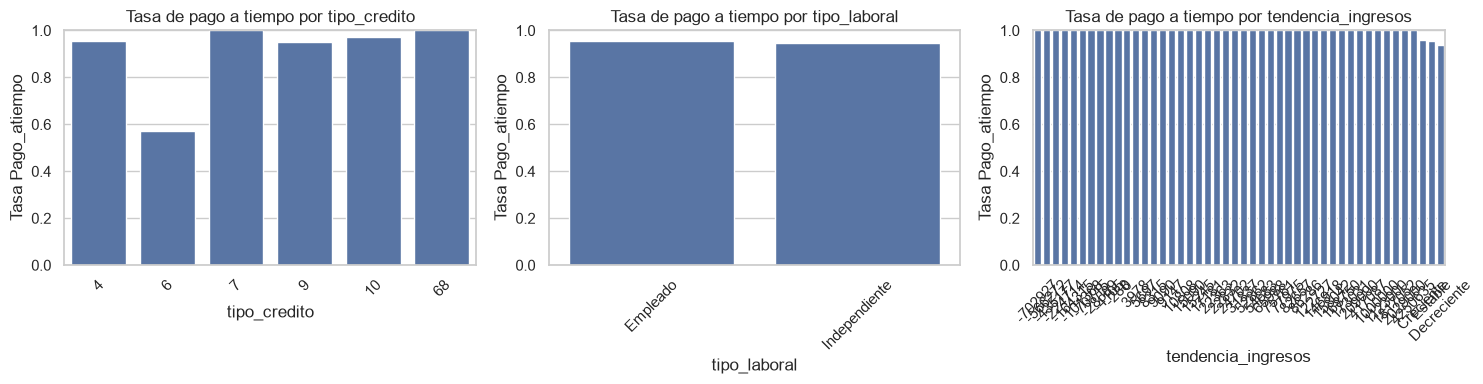

In [16]:
fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 4))

for ax, col in zip(axes, cat_cols):
    tasa = df.groupby(col)[TARGET].mean().sort_values(ascending=False)
    sns.barplot(x=tasa.index, y=tasa.values, ax=ax)
    ax.set_title(f"Tasa de pago a tiempo por {col}")
    ax.set_ylabel("Tasa Pago_atiempo")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 10. Conclusiones preliminares

**Desbalance de clases.** `Pago_atiempo` está fuertemente desbalanceada: 95.25% de los créditos se pagaron a tiempo frente a solo 4.75% que no. Cualquier modelo posterior debe evaluarse con métricas robustas al desbalance (precision, recall, F1, AUC-ROC) en lugar de accuracy, y conviene considerar técnicas de remuestreo o ponderación de clases.

**Valores nulos.** No hay filas duplicadas. Las columnas con más nulos son `tendencia_ingresos` (27.24%) y `promedio_ingresos_datacredito` (27.22%) — faltan juntas en las mismas filas, probablemente por ausencia de reporte de Datacrédito para esos clientes. Le siguen `saldo_mora_codeudor` (5.48%), `saldo_principal` (3.76%), `saldo_mora`/`saldo_total` (1.45% cada una) y `puntaje_datacredito` (0.06%, prácticamente despreciable).

**Outliers y valores fuera de rango.** `describe()` muestra varios casos que hay que tratar antes de modelar:
- `salario_cliente` y `total_otros_prestamos` tienen máximos extremos (hasta 2.2×10¹⁰ y 6.8×10⁹) muy alejados de la media, sugiriendo errores de carga o casos atípicos reales que deben revisarse puntualmente.
- `edad_cliente` llega a 123 años, un valor no plausible.
- `puntaje` tiene un mínimo de -38 y `puntaje_datacredito` un mínimo de -7, ambos negativos pese a ser puntajes de score — indican valores inválidos a limpiar.

**Calidad de `tendencia_ingresos`.** Además de sus nulos, la columna mezcla las categorías esperadas (`Creciente`, `Decreciente`, `Estable`) con ~44 registros que contienen valores numéricos (positivos y negativos, ej. `8315`, `-566272`, `1000000`) que no corresponden a una categoría válida. Esto apunta a un problema de origen en la carga/generación del dato que debe corregirse (mapear, descartar o imputar) antes de usar la variable.

**`tipo_credito` muy concentrado.** El 98% de los registros corresponde a los códigos 4 y 9; el código 68 aparece una sola vez y probablemente sea un error de tipeo (¿6 u 8?) a validar con el área de negocio.

**Relación con la variable objetivo.** `puntaje` es la única variable con correlación fuerte respecto a `Pago_atiempo` (0.92). Dado que un puntaje de crédito suele calcularse a partir del comportamiento de pago histórico, existe riesgo de fuga de información (data leakage) si se usa tal cual como feature — se debe confirmar con el negocio cómo y cuándo se calcula `puntaje` antes de incluirlo en el modelo. El resto de las variables numéricas muestra correlación lineal individual muy baja (todas por debajo de 0.08) con el target, y en los boxplots categóricos (`tipo_laboral`, `tendencia_ingresos`) no se observan diferencias grandes en la tasa de pago a tiempo entre grupos — sugiere que el poder predictivo probablemente vendrá de combinaciones de variables más que de relaciones univariadas.

**Próximos pasos.** Limpiar valores negativos/fuera de rango en `puntaje`, `puntaje_datacredito` y `edad_cliente`; decidir tratamiento de nulos (imputación vs. exclusión) especialmente en `tendencia_ingresos` y `promedio_ingresos_datacredito`; normalizar las categorías inválidas de `tendencia_ingresos`; y definir si `puntaje` se mantiene como feature o se excluye por fuga de información antes de pasar a la etapa de modelado.